# Assignment 6: Emotion Classification

**Data:**

The dataset is available at Emotion Classification NLP | Kaggle . Acknowledgment: WASSA-2017 Shared Task on Emotion Intensity. Saif M. Mohammad and Felipe Bravo-Marquez. In Proceedings of the EMNLP 2017 Workshop on Computational Approaches to Subjectivity, Sentiment, and Social Media (WASSA), September 2017, Copenhagen, Denmark. 

**Problem Statement:**

Identifying the emotion behind human text is an important part of NLP for various applications including customer review analysis and artificial intelligence. The owner of Twitter, Elon Musk has fired everyone who understood emotion classification of tweets because they were not "hard core" enough, and now their existing model is no longer working. As a new employee, your job is to develop a model that can classify the emotional connotation behind tweets. Mr. Musk does not disclose why this is needed but laughs eerily whenever asked about it.

# 1. Data
## 1.1 Load Data
Load the three datafiles into training, validation, and testing dataframes.

In [1]:
import pandas as pd
df_train = pd.read_csv('datasets/emotion-labels-train.csv')
df_validation = pd.read_csv('datasets/emotion-labels-val.csv')
df_test = pd.read_csv('datasets/emotion-labels-test.csv')

In [2]:
df_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


## 1.2 Validating Datasets
Use pandas.DataFrame.info to check if the entries are the correct datatype, and if there are any missing values. Use pandas.DataFrame.duplicates to check for duplicate entries. Fix the dataset so that there are no missing values, duplicate rows, or incorrect data types. Use markdown to make observations and explain what you have done.

### Missingness Check

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3613 entries, 0 to 3612
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3613 non-null   object
 1   label   3613 non-null   object
dtypes: object(2)
memory usage: 56.6+ KB


In [4]:
df_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    347 non-null    object
 1   label   347 non-null    object
dtypes: object(2)
memory usage: 5.5+ KB


In [5]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    3142 non-null   object
 1   label   3142 non-null   object
dtypes: object(2)
memory usage: 49.2+ KB


### Duplicates Check

In [6]:
print("Train:", df_train.duplicated().sum())
print("Validation:", df_validation.duplicated().sum())
print("Test:", df_test.duplicated().sum())

Train: 0
Validation: 0
Test: 0


No missing values or duplicates were found on any of the datasets

## 1.3 Separating Labels
Move the labels into a separate dataframe and use sklearn.preprocessing.LabelEncoder to convert the string labels into integers. Reshape the labels into a 2d array. Determine which number has been assigned to each label and record this information in markdown.

In [7]:
df_train_labels = df_train['label']
df_validation_labels = df_validation['label']
df_test_labels = df_test['label']

In [8]:
# LabelEncoder to convert the strung labels to integers
import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train_labels = le.fit_transform(df_train_labels)
df_validation_labels = le.transform(df_validation_labels)
df_test_labels = le.transform(df_test_labels)

all_labels = np.concatenate((df_train_labels, df_validation_labels, df_test_labels))

In [9]:
id_to_label = {i: label for i, label in enumerate(le.classes_)}
print(id_to_label)

{0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'}


We can see that 0 corresponds to anger, 1 corresponds to fear, 2 corresponds to joy and 3 corresponds to sadness.

## 1.4 Bar Plot
Create a bar plot using seaborn.barplot of the number of elements in each category over the entire dataset. Use markdown to comment on how well balanced the dataset is.

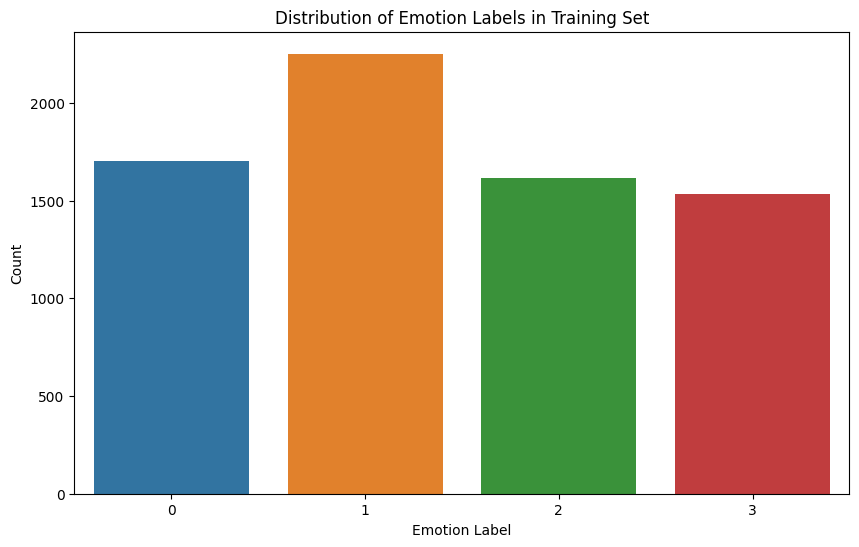

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x=all_labels)
plt.title('Distribution of Emotion Labels in Training Set')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.show()

## 1.5 Preprocessing
Perform the following steps on the tweets in an order of your choosing:
- Tokenize each tweet into words.
- If you think it is useful, use Speller from the autocorrect library to correct spelling mistakes. 
- Create a list of stopwords (using publicly available lists and/or adding your own) and remove these.
- Use PorterStemmer or WordNetLemmatizer from nltk.stem on the text.
- Use regular expressions (the re library) to do any additional cleanup of the text you wish to do.

In [11]:
import re
import nltk
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer

try:
    from autocorrect import Speller
    speller = Speller(lang="en")
except Exception:
    speller = None
    print("autocorrect not found; continuing without spelling correction.")

for resource in ["stopwords", "wordnet", "omw-1.4", "averaged_perceptron_tagger"]:
    nltk.download(resource, quiet=True)

tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=False)
lemmatizer = WordNetLemmatizer()

custom_stopwords = {
    "rt", "amp", "im", "ive", "dont", "didnt", "cant", "wont",
    "u", "ur", "via"
}
stop_words = set(stopwords.words("english")).union(custom_stopwords)

def to_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    if treebank_tag.startswith("V"):
        return wordnet.VERB
    if treebank_tag.startswith("N"):
        return wordnet.NOUN
    if treebank_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def preprocess_tweet(text, use_speller=False):
    text = str(text).lower()

    # Regex cleanup: URLs, mentions, hashtags, and non-letter characters
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = tokenizer.tokenize(text)

    if use_speller and speller is not None:
        tokens = [speller(t) if t.isalpha() else t for t in tokens]

    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    if tokens:
        tagged = pos_tag(tokens)
        tokens = [lemmatizer.lemmatize(tok, to_wordnet_pos(tag)) for tok, tag in tagged]

    clean_text = " ".join(tokens)
    return tokens, clean_text

def preprocess_dataframe(df, text_col="tweet", use_speller=False):
    processed = df[text_col].apply(lambda x: preprocess_tweet(x, use_speller=use_speller))
    out = df.copy()
    out["tokens"] = processed.apply(lambda x: x[0])
    out["clean_text"] = processed.apply(lambda x: x[1])
    return out

text_col = "tweet" if "tweet" in df_train.columns else "text"
if text_col not in df_train.columns:
    raise KeyError("Expected a text column named 'tweet' or 'text'.")

df_train_pp = preprocess_dataframe(df_train, text_col=text_col, use_speller=False)
df_validation_pp = preprocess_dataframe(df_validation, text_col=text_col, use_speller=False)
df_test_pp = preprocess_dataframe(df_test, text_col=text_col, use_speller=False)

df_train_pp[[text_col, "tokens", "clean_text"]].head()

,text,tokens,clean_text
0,Just got back from seeing @GaryDelaney in Burs...,"[get, back, see, burslem, amaze, face, still, ...",get back see burslem amaze face still hurt lau...
1,Oh dear an evening of absolute hilarity I don'...,"[oh, dear, even, absolute, hilarity, think, la...",oh dear even absolute hilarity think laugh muc...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,"[wait, week, game, cheer, friday]",wait week game cheer friday
3,"@gardiner_love : Thank you so much, Gloria! Yo...","[thank, much, gloria, sweet, thoughtful, make,...",thank much gloria sweet thoughtful make day jo...
4,I feel so blessed to work with the family that...,"[feel, bless, work, family, nanny, nothing, lo...",feel bless work family nanny nothing love appr...


## 1.6 Printing Processed Tweets
Print out the words in the first five processed tweets along with their labels. (Viewing this may give you additional ideas for the previous steps.)

In [16]:
for tweet in df_train_pp[['text','clean_text','label']].tail(5).iterrows():
    print(f"Tweet: {tweet[1]['text']}")
    print(f"Cleaned Tweet: {tweet[1]['clean_text']}")
    print(f"Label: {tweet[1]['label']}")
    print()

Tweet: @VivienLloyd Thank you so much! Just home - stunned but so happy. Don't think it has sunk in yet! Wow.
Cleaned Tweet: thank much home stun happy think sunk yet wow
Label: sadness

Tweet: Just put the winter duvet on ☃️❄️🌬☔️ 
Cleaned Tweet: put winter duvet
Label: sadness

Tweet: @SilkInSide @TommyJoeRatliff that's so pretty! I love the sky in the background and the purple highlights with the dull colors is great
Cleaned Tweet: that's pretty love sky background purple highlight dull color great
Label: sadness

Tweet: @BluesfestByron second artist announcement looking good #bluesfest2017 #blues #Music #byronbay
Cleaned Tweet: second artist announcement look good bluesfest blue music byronbay
Label: sadness

Tweet: I can literally eat creamy pesto pasta topped with grilled chicken, sun dried tomatoes, asparagus and pine nuts every single day of my life
Cleaned Tweet: literally eat creamy pesto pasta top grilled chicken sun dry tomato asparagus pine nut every single day life
Label: 

## 1.7 Histogram Showing the Lengths
Create a histogram showing the lengths of the sequences after preprocessing. Comment on how this helps you to choose the maximum length hyperparameter used when truncating/padding the input sequences.

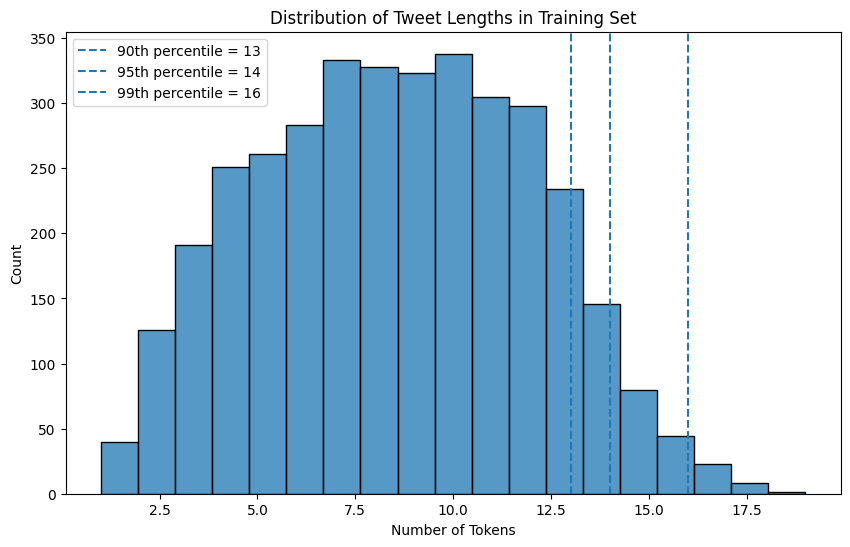

In [30]:
df_train_pp['lenght'] = df_train_pp['tokens'].apply(len)
# Creating a histogram of tweet lengths

p90 = np.percentile(df_train_pp['lenght'], 90)
p95 = np.percentile(df_train_pp['lenght'], 95)
p99 = np.percentile(df_train_pp['lenght'], 99)

plt.figure(figsize=(10, 6))
sns.histplot(df_train_pp['lenght'], bins=19)

plt.axvline(p90, linestyle='--', label=f'90th percentile = {int(p90)}')
plt.axvline(p95, linestyle='--', label=f'95th percentile = {int(p95)}')
plt.axvline(p99, linestyle='--', label=f'99th percentile = {int(p99)}')
 
plt.title('Distribution of Tweet Lengths in Training Set')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()
plt.show()


According to the results we obtained, we decided to pick 16 as our maximun length as it covers 99% of the different lenghts of our tweets tokens, covering most of the length cases.